# Test-fragment inference viewer for the Campaign 38 native-96 comparison

Loads two saved runs, `holdout_n96_combined` and `holdout_n96_surface_norm`, and renders only `PHerc0211_z7312_w080_abf`.

Figures are saved to `output/test_visualizations/<run>/`. The fast figure `<name>_fast.jpg` is always generated and previewed inline at 1/3 scale:

| depth estimate | composite (1 cm scale bar) |
|---|---|

With `FAST_EVAL = False` (cell 2), the full 2x6 figure `<name>.jpg` is also saved:

| depth estimate | depth estimate +2 | depth estimate -2 | max of (0, +2, -2) | composite (scale bar) | composite |
|---|---|---|---|---|---|
| **d=0→8** | **d=4→12** | **d=8→16** | **d=12→20** | **d=20→28** | **max of fixed windows** |

- each run replays its own saved config, so model geometry and features such as the fiber-coordinate branch match training
- checkpoints are resolved from each run's saved `model_dir`, then loaded strictly after removing training-only heads
- normalization follows each run's `data.norm_mode`, which is required for `holdout_n96_surface_norm`
- the volume crop is loaded once per render and reused for every inference pass
- inference and composites are restricted to the tile-aligned nonzero data bounds
- the visualizer module is reloaded so stale notebook kernels cannot retain an older implementation
- missing zarrs, norms, and surface labels are generated on demand for the target fragment
- set `DRY_RUN = True` in cell 3 to inspect composites without loading the models


In [16]:
# True: only the fast depth-estimate | composite figure; False: also the full 2x6 figure
FAST_EVAL = True

import os
from pathlib import Path

RUN_ROOT = Path(os.getenv("VESUVIUS_RUN_ROOT", "/vesuvius/runs_archs37"))
MODEL_SPECS = [
    {
        "name": "holdout_n96_combined",
        "exp_name": os.getenv("VESUVIUS_EXP_NAME_COMBINED", "38_holdout_n96_combined"),
        "run_id": os.getenv("VESUVIUS_RUN_ID_COMBINED", "38_holdout_n96_combined_29_16-24-37"),
        "model_env": "VESUVIUS_MODEL_PATH_COMBINED",
        "checkpoint_name": os.getenv("VESUVIUS_CHECKPOINT_COMBINED", "final_best_character.pth"),
    },
    {
        "name": "holdout_n96_surface_norm",
        "exp_name": os.getenv("VESUVIUS_EXP_NAME_SURFACE_NORM", "38_holdout_n96_surface_norm"),
        "run_id": os.getenv("VESUVIUS_RUN_ID_SURFACE_NORM", "38_holdout_n96_surface_norm_29_20-09-34"),
        "model_env": "VESUVIUS_MODEL_PATH_SURFACE_NORM",
        "checkpoint_name": os.getenv("VESUVIUS_CHECKPOINT_SURFACE_NORM", "final_best_character.pth"),
    },
]
TARGET_NAME = "PHerc0211_z7312_w080_abf"
TARGET_SCROLL_ID = 20260928000003


In [17]:
# campaign-38 run selection: config and checkpoint both come from the same saved run
import json

DRY_RUN = False
MODEL_ROOT = Path(os.getenv("VESUVIUS_MODEL_ROOT", "/vesuvius"))

# inference window step in px (<= multitile_grid * multitile_subtile); 16 = densest, 32 = ~4x faster
EVAL_STRIDE = 32
PRELOAD_RAM = True
TORCH_COMPILE = False
COMPOSITE_METHOD = "maxproj"
COMPOSITE_D0 = 10
COMPOSITE_D1 = 18
COMPOSITE_DISPLAY = "raw"
COMPOSITE_CLAHE = False
GENERATE_COMPOSITES = False
VOXEL_UM = 9.362
DISPLAY_SCALE = 0.25
MASK_CROP_MARGIN = 32
PAD_PX = 24
OUTPUT_DIR = "output"
COMPOSITE_CACHE = "output/composite_cache"
FRAGMENTS = {
    TARGET_NAME: TARGET_SCROLL_ID,
}
# extra segment sets live in dedicated subfolders under masks/ and surface_labels/
EXTRAS_SUBDIR = "extras"


def resolve_run(spec):
    run_root = Path(spec.get("run_root", RUN_ROOT))
    exp_name = spec["exp_name"]
    run_id = spec.get("run_id") or None
    run_dir = run_root / run_id if run_id else None
    run_config_path = run_dir / "config.json" if run_dir is not None else None
    if run_config_path is None or not run_config_path.is_file():
        candidates = sorted(run_root.glob(f"{exp_name}_*/config.json"), key=lambda path: path.stat().st_mtime)
        if not candidates:
            raise FileNotFoundError(f"no run config matching {exp_name!r} under {run_root}")
        run_config_path = candidates[-1]
        run_dir = run_config_path.parent
        run_id = run_dir.name

    with open(run_config_path, "r", encoding="utf-8") as handle:
        run_config = json.load(handle)
    run_data = run_config["data"]
    run_model = run_config["model"]
    default_model_path = MODEL_ROOT / run_config["model_dir"] / spec["checkpoint_name"]
    model_path = Path(os.getenv(spec["model_env"], str(default_model_path)))
    if not model_path.is_file():
        raise FileNotFoundError(f"checkpoint for {exp_name} is missing: {model_path}")
    if Path(run_config["model_dir"]).name != model_path.parent.name:
        raise RuntimeError(
            f"checkpoint {model_path} does not belong to run model_dir {run_config['model_dir']}"
        )

    run = {
        "name": spec["name"],
        "exp_name": exp_name,
        "run_root": run_root,
        "run_dir": run_dir,
        "run_id": run_id,
        "run_config_path": run_config_path,
        "run_config": run_config,
        "run_data": run_data,
        "run_model": run_model,
        "model_path": model_path,
        "tile_size": int(run_data["tile_size"]),
        "context_size": int(run_data["context_size"]),
        "context_downsample": int(run_data["context_downsample"]),
        "depth": int(run_data["depth"]),
        "d_start": int(run_data["d_start"]),
        "d_end": int(run_data["d_end"]),
        "multitile": bool(run_model["multitile"]),
        "multitile_subtile": int(run_model["multitile_subtile"]),
        "multitile_grid": int(run_model["multitile_grid"]),
        "tta_mode": run_data["tta_mode"],
        "norm_mode": str(run_data.get("norm_mode", "global")),
    }
    if run["depth"] != 8 or not run_model.get("surface_teacher_input") or not run_data.get("surface_relative_depth_window"):
        raise RuntimeError(f"selected run is not literal-surface true slice-8: {run_id}")
    if not run_model.get("early_2d_unet") or not run_model.get("gated_stems"):
        raise RuntimeError(f"selected run is not an early-2D gated model: {run_id}")
    if EVAL_STRIDE > run["multitile_grid"] * run["multitile_subtile"]:
        raise RuntimeError(
            f"EVAL_STRIDE={EVAL_STRIDE} exceeds the {run['multitile_grid'] * run['multitile_subtile']}px multitile output for {run_id}"
        )
    run_data["eval_stride"] = EVAL_STRIDE
    return run


MODEL_RUNS = [resolve_run(spec) for spec in MODEL_SPECS]
GEOMETRY = {
    (
        run["tile_size"],
        run["context_size"],
        run["context_downsample"],
        run["depth"],
        run["multitile_subtile"],
        run["multitile_grid"],
    )
    for run in MODEL_RUNS
}
if len(GEOMETRY) != 1:
    raise RuntimeError(f"selected runs do not share one evaluation geometry: {GEOMETRY}")

TILE_SIZE = MODEL_RUNS[0]["tile_size"]
CONTEXT_SIZE = MODEL_RUNS[0]["context_size"]
CONTEXT_DOWNSAMPLE = MODEL_RUNS[0]["context_downsample"]
DEPTH = MODEL_RUNS[0]["depth"]
D_START = MODEL_RUNS[0]["d_start"]
D_END = MODEL_RUNS[0]["d_end"]
MULTITILE = MODEL_RUNS[0]["multitile"]
MULTITILE_SUBTILE = MODEL_RUNS[0]["multitile_subtile"]
MULTITILE_GRID = MODEL_RUNS[0]["multitile_grid"]
TTA = False
TTA_MODE = MODEL_RUNS[0]["tta_mode"]


def is_extra(scroll_id):
    return not str(scroll_id).isdigit()


def mask_dir_for(scroll_id):
    return os.path.join("masks", EXTRAS_SUBDIR) if is_extra(scroll_id) else "masks"


def mask_path_for(scroll_id):
    return os.path.join(mask_dir_for(scroll_id), f"{scroll_id}.png")


def surface_root_for(config, scroll_id):
    root = config.data.surface_label_dir
    return os.path.join(root, EXTRAS_SUBDIR) if is_extra(scroll_id) else root

for run in MODEL_RUNS:
    print(
        run["run_id"],
        run["model_path"],
        f"depth={run['depth']}",
        f"norm={run['norm_mode']}",
        f"fiber={run['run_model'].get('fiber_coordinate_branch')}",
        f"ctx={run['context_size']}/ds{run['context_downsample']}",
        f"stride={EVAL_STRIDE}",
    )


38_holdout_n96_combined_29_16-24-37 /vesuvius/models/archs38/holdout_n96_combined/final_best_character.pth depth=8 norm=global fiber=True ctx=96/ds1 stride=32
38_holdout_n96_surface_norm_29_20-09-34 /vesuvius/models/archs38/holdout_n96_surface_norm/final_best_character.pth depth=8 norm=surface_anchor fiber=False ctx=96/ds1 stride=32


In [18]:
import gc
import importlib
import os
import sys
import types

REPO = os.getenv("VESUVIUS_REPO", "/vesuvius" if os.name == "posix" else r"C:\Users\ChenJeff\Documents\vesuvius")
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import zarr
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

from utils.config import Config
from utils.model import create_model
from utils.norm import compute_norm, load_cached_norm
from utils import visualizer as visualizer_module

# reload the bounded-memory row reader in existing kernels
visualizer_module = importlib.reload(visualizer_module)
TBV = visualizer_module.TensorboardVisualizer
group_by_depth = visualizer_module.group_by_depth
predict_tiles = visualizer_module.predict_tiles
load_or_create_midslice_mask = visualizer_module.load_or_create_midslice_mask

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPOSITE_CACHE, exist_ok=True)
print(
    f"repo={REPO}",
    f"| torch={torch.__version__}",
    f"| cuda={torch.cuda.is_available()}",
    f"| dry_run={DRY_RUN}",
    "| bounded-memory visualizer reloaded",
)


repo=/vesuvius | torch=2.1.0+cu118 | cuda=True | dry_run=False | bounded-memory visualizer reloaded


/vesuvius/utils/visualizer.py:60: UserWarning: Overwriting the cmap 'inferno_nan' that was already in the registry.
  _mpl.colormaps.register(_inferno_nan, name='inferno_nan', force=True)
/vesuvius/utils/visualizer.py:61: UserWarning: Overwriting the cmap 'ylgnbu_nan' that was already in the registry.
  _mpl.colormaps.register(_ylgnbu_nan, name='ylgnbu_nan', force=True)
/vesuvius/utils/visualizer.py:62: UserWarning: Overwriting the cmap 'purples_nan' that was already in the registry.
  _mpl.colormaps.register(_purples_nan, name='purples_nan', force=True)
/vesuvius/utils/visualizer.py:63: UserWarning: Overwriting the cmap 'ink_gray_nan' that was already in the registry.
  _mpl.colormaps.register(_ink_gray_nan, name='ink_gray_nan', force=True)


In [19]:
# composite helper and projection settings
def _project_depth(vol, d0, d1, method, bounds=None):
    """project only the requested spatial bounds over slices [d0, d1)"""
    _, height, width = map(int, vol.shape)
    y0, y1, x0, x1 = bounds or (0, height, 0, width)
    d0, d1 = max(0, d0), min(d1, int(vol.shape[0]))
    shape = (y1 - y0, x1 - x0)
    if method == "maxproj":
        acc = np.zeros(shape, np.float32)
        for depth in range(d0, d1):
            acc = np.maximum(acc, np.asarray(vol[depth, y0:y1, x0:x1]).astype(np.float32))
        return acc
    if method == "meanproj":
        acc = np.zeros(shape, np.float64)
        for depth in range(d0, d1):
            acc += np.asarray(vol[depth, y0:y1, x0:x1])
        return (acc / max(d1 - d0, 1)).astype(np.float32)
    if method == "minproj":
        acc = np.full(shape, np.inf, np.float32)
        for depth in range(d0, d1):
            acc = np.minimum(acc, np.asarray(vol[depth, y0:y1, x0:x1]).astype(np.float32))
        return np.where(np.isfinite(acc), acc, 0).astype(np.float32)
    if method == "stdproj":
        total = np.zeros(shape, np.float64)
        total_squared = np.zeros(shape, np.float64)
        for depth in range(d0, d1):
            layer = np.asarray(vol[depth, y0:y1, x0:x1]).astype(np.float64)
            total += layer
            total_squared += layer * layer
        count = max(d1 - d0, 1)
        mean = total / count
        return np.sqrt(np.clip(total_squared / count - mean * mean, 0, None)).astype(np.float32)
    if method == "midslice":
        return np.asarray(vol[(d0 + d1) // 2, y0:y1, x0:x1]).astype(np.float32)
    raise ValueError(f"unknown composite method: {method}")


def _display_map(proj, mask, mode, use_clahe):
    """map a float projection to uint8 for display"""
    if mode == "raw":
        image = np.clip(proj, 0, 255).astype(np.uint8)
    else:
        lo, hi = np.percentile(proj[mask], [1, 99]) if mask.any() else (float(proj.min()), float(proj.max()))
        display = np.clip((proj - lo) / max(hi - lo, 1e-6), 0, 1)
        image = (display * 255).astype(np.uint8)
    if use_clahe:
        image = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(image)
    return image * mask.astype(np.uint8)


def make_composite(zarr_path, scroll_id, bounds, method=None, d0=None, d1=None, use_cache=True, display=None, clahe=None):
    """return a uint8 fiber composite restricted to the data bbox"""
    method = method or COMPOSITE_METHOD
    display = display or COMPOSITE_DISPLAY
    clahe = COMPOSITE_CLAHE if clahe is None else clahe
    vol = zarr.open(os.path.join(zarr_path, f"{scroll_id}.zarr"), mode="r")
    depth_count = int(vol.shape[0])
    d0 = COMPOSITE_D0 if d0 is None else d0
    d1 = (COMPOSITE_D1 if COMPOSITE_D1 is not None else depth_count) if d1 is None else d1
    d0, d1 = max(0, d0), min(d1, depth_count)
    y0, y1, x0, x1 = bounds
    display_tag = f"_{display}" + ("_clahe" if clahe else "")
    mask_path = mask_path_for(scroll_id)
    if is_extra(scroll_id):
        cache_path = os.path.join(COMPOSITE_CACHE, EXTRAS_SUBDIR, f"{scroll_id}_{method}_{d0}-{d1}_full{display_tag}.png")
        if not (use_cache and not GENERATE_COMPOSITES and os.path.exists(cache_path)):
            full_mask = np.array(Image.open(mask_path).convert("L")) > 0
            image = _display_map(_project_depth(vol, d0, d1, method), full_mask, display, clahe)
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            Image.fromarray(image).save(cache_path)
            print(f"[composite] {scroll_id} {method} d{d0}-{d1} full{display_tag} -> {cache_path} {image.shape}")
        return np.array(Image.open(cache_path).convert("L"))[y0:y1, x0:x1]
    bounds_tag = f"y{y0}-{y1}_x{x0}-{x1}"
    cache_path = os.path.join(
        COMPOSITE_CACHE,
        f"{scroll_id}_{method}_{d0}-{d1}_{bounds_tag}{display_tag}.png",
    )
    if use_cache and not GENERATE_COMPOSITES and os.path.exists(cache_path):
        return np.array(Image.open(cache_path).convert("L"))
    full_mask = (np.array(Image.open(mask_path).convert("L")) > 0) if os.path.exists(mask_path) else None
    proj = _project_depth(vol, d0, d1, method, bounds=bounds)
    mask = full_mask[y0:y1, x0:x1] if full_mask is not None else (proj > 0)
    image = _display_map(proj, mask, display, clahe)
    Image.fromarray(image).save(cache_path)
    print(f"[composite] {scroll_id} {method} d{d0}-{d1} {bounds_tag}{display_tag} -> {cache_path} {image.shape}")
    return image


In [20]:
# inference and reusable figure builder
import copy

from IPython.display import display
from matplotlib.patches import Rectangle
from utils.config import ScrollConfig

_TRAINING_ONLY_PREFIXES = ("supcon_head.", "domain_head.", "dg_head.")
SURFACE_SHIFTS = (0, 2, -2)
FIXED_WINDOW_STARTS = (0, 4, 8, 12, 20)
# matplotlib/agg and jpeg both cap each image dimension below 2**16 px
MAX_FIGURE_PX = 65000
PREVIEW_DOWNSCALE = 3
FIGURE_DPI = 100
# inverted grayscale: 0 (papyrus) = white, 1 (ink) = black; masked-out cells pale blue
PRED_CMAP = plt.get_cmap("gray_r").copy()
PRED_CMAP.set_bad((0.78, 0.86, 0.95))


def build_config(run_info):
    config = Config()
    run_data = run_info["run_data"]
    run_model = run_info["run_model"]
    # replay the full saved run config so geometry and feature flags match training
    for name, value in run_data.items():
        if name == "scrolls":
            config.data.scrolls = [ScrollConfig(**item) for item in value]
        elif name != "probe_rois" and hasattr(config.data, name):
            setattr(config.data, name, value)
    for name, value in run_model.items():
        if hasattr(config.model, name):
            setattr(config.model, name, value)
    config.model.compile_model = False
    config.tra.supcon = False
    config.tra.dann = False
    config.device = "cuda" if torch.cuda.is_available() else "cpu"
    return config


def _checkpoint_state(path):
    state = torch.load(path, map_location="cpu", weights_only=True)
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    cleaned = {}
    for key, value in state.items():
        key = key.removeprefix("module.").removeprefix("_orig_mod.")
        if not key.startswith(_TRAINING_ONLY_PREFIXES):
            cleaned[key] = value
    return cleaned, len(state) - len(cleaned)


def load_model(config, run_info):
    model, parameter_count = create_model(config)
    state, ignored = _checkpoint_state(run_info["model_path"])
    model.load_state_dict(state, strict=True)
    model.eval()
    if TORCH_COMPILE:
        model = torch.compile(model, mode="reduce-overhead")
    print(f"loaded {run_info['model_path']} params={parameter_count:,} ignored_training_only={ignored}")
    return model


def get_norm(config, scroll_id):
    mode = str(getattr(config.data, "norm_mode", "global"))
    try:
        stats = load_cached_norm(scroll_id, mode=mode)
    except RuntimeError:
        stats = None
    if stats is not None:
        return stats
    if load_cached_norm(scroll_id, mode="global") is None:
        compute_norm(scroll_id, config.data.zarr_path, mask_dir=os.path.join(REPO, mask_dir_for(scroll_id)))
    stats = load_cached_norm(scroll_id, mode=mode)
    if stats is None:
        raise RuntimeError(f"normalization cache missing for {scroll_id} in mode {mode!r}")
    return stats


def _mask_bbox(mask_bool, margin, align):
    """return an outward tile-aligned bbox around nonzero data"""
    ys, xs = np.where(mask_bool)
    if ys.size == 0:
        return 0, mask_bool.shape[0], 0, mask_bool.shape[1]
    align = max(1, int(align))
    y0 = max(0, ((int(ys.min()) - margin) // align) * align)
    x0 = max(0, ((int(xs.min()) - margin) // align) * align)
    y1 = min(mask_bool.shape[0], ((int(ys.max()) + 1 + margin + align - 1) // align) * align)
    x1 = min(mask_bool.shape[1], ((int(xs.max()) + 1 + margin + align - 1) // align) * align)
    return y0, y1, x0, x1


def load_inputs(config, scroll_id, bounds):
    """load volume, mask, norm, surface maps, and tile coords once for all passes"""
    import time as _time

    source = zarr.open(os.path.join(config.data.zarr_path, f"{scroll_id}.zarr"), mode="r")
    mask_full = np.array(Image.open(mask_path_for(scroll_id)).convert("L")) > 0
    y0, y1, x0, x1 = bounds
    if PRELOAD_RAM:
        t0 = _time.time()
        print(f"[preload] {scroll_id} bbox={bounds} -> RAM ... ", end="", flush=True)
        vol = np.asarray(source[:, y0:y1, x0:x1])
        mask = mask_full[y0:y1, x0:x1]
        y_range, x_range = (0, y1 - y0), (0, x1 - x0)
        print(f"done in {_time.time() - t0:.1f}s", flush=True)
    else:
        vol = source
        mask = mask_full
        y_range, x_range = (y0, y1), (x0, x1)
    norm = get_norm(config, scroll_id)
    surface_dir = os.path.join(surface_root_for(config, scroll_id), str(scroll_id))
    surface_depth = np.load(os.path.join(surface_dir, "depth.npy"), mmap_mode="r")
    surface_confidence = np.load(os.path.join(surface_dir, "confidence.npy"), mmap_mode="r")
    if PRELOAD_RAM:
        surface_depth = surface_depth[y0:y1, x0:x1]
        surface_confidence = surface_confidence[y0:y1, x0:x1]
    fake = types.SimpleNamespace(c=config)
    coords = TBV._gen_tile_coords(
        fake,
        (config.data.d_start, config.data.d_end),
        y_range,
        x_range,
        mask,
        z_step=config.data.depth,
    )
    grouped = group_by_depth(coords)
    if len(grouped) != 1:
        raise RuntimeError(f"surface-relative inference expected one depth pass, got {len(grouped)}")
    depth_offset = next(iter(grouped))
    return {
        "scroll_id": scroll_id,
        "vol": vol,
        "mask": mask,
        "y_range": y_range,
        "x_range": x_range,
        "norm": norm,
        "surface_depth": surface_depth,
        "surface_confidence": surface_confidence,
        "coords": grouped[depth_offset],
        "depth_start": config.data.d_start + depth_offset,
    }


def predict_map(model, config, inputs, surface_shift=0, depth_start=None):
    """surface-relative pass shifted by surface_shift, or a fixed window when depth_start is set"""
    if depth_start is None:
        pass_config, start, tag = config, inputs["depth_start"], f"surface{surface_shift:+d}"
    else:
        pass_config = copy.deepcopy(config)
        pass_config.data.surface_relative_depth_window = False
        start, tag = int(depth_start), f"d{depth_start}-{depth_start + config.data.depth}"
    return predict_tiles(
        pass_config,
        model,
        inputs["vol"],
        inputs["mask"],
        inputs["coords"],
        inputs["y_range"],
        inputs["x_range"],
        start,
        f"test_{inputs['scroll_id']}_{tag}",
        *inputs["norm"],
        surface_depth_map=inputs["surface_depth"],
        surface_confidence_map=inputs["surface_confidence"],
        surface_depth_offset=surface_shift,
    )


def _nan_max(maps):
    return np.fmax.reduce(np.stack(maps), axis=0)


def _run_name(run_info):
    return run_info["run_id"]


def _draw_scale_bar(ax, panel_hw, px_scale, font_pt):
    """red 1 cm bar in the bottom-right corner, in panel pixel coordinates"""
    height, width = panel_hw
    length = 10000.0 / VOXEL_UM * px_scale
    thickness = max(2.0, min(height, width) / 250)
    pad = 0.05 * min(height, width) + thickness
    if width >= height:
        x1, y = width - pad, height - pad
        x0 = max(0.0, x1 - length)
        ax.add_patch(Rectangle((x0, y - thickness), x1 - x0, thickness, color="red"))
        ax.text(x0, y - 3 * thickness, "1 cm", color="red", fontsize=font_pt, ha="left", va="bottom")
    else:
        y1, x = height - pad, width - pad
        y0 = max(0.0, y1 - length)
        ax.add_patch(Rectangle((x - thickness, y0), thickness, y1 - y0, color="red"))
        ax.text(x, y0 - 2 * thickness, "1 cm", color="red", fontsize=font_pt, ha="right", va="bottom")


def _save_figure(rows, crop_hw, out_path):
    """lay out (title, image, kind) rows on a pixel-exact grid and save it"""
    crop_height, crop_width = crop_hw
    n_rows, n_cols = len(rows), max(len(row) for row in rows)
    gap = max(PAD_PX, crop_width // 40)
    title_h = max(60, crop_height // 14)
    fig_w = n_cols * crop_width + (n_cols + 1) * gap
    fig_h = n_rows * (title_h + crop_height) + (n_rows + 1) * gap
    scale = min(1.0, MAX_FIGURE_PX / fig_w, MAX_FIGURE_PX / fig_h)
    panel_hw = (max(1, int(crop_height * scale)), max(1, int(crop_width * scale)))
    title_pt = title_h * scale * 0.45 * 72 / FIGURE_DPI
    fig = plt.figure(figsize=(fig_w * scale / FIGURE_DPI, fig_h * scale / FIGURE_DPI), dpi=FIGURE_DPI, facecolor="white")
    for r, row in enumerate(rows):
        row_top = gap + r * (title_h + crop_height + gap) + title_h
        for c, (title, image, kind) in enumerate(row):
            ax = fig.add_axes([
                (gap + c * (crop_width + gap)) / fig_w,
                1 - (row_top + crop_height) / fig_h,
                crop_width / fig_w,
                crop_height / fig_h,
            ])
            if kind.startswith("composite"):
                small = cv2.resize(image, (panel_hw[1], panel_hw[0]), interpolation=cv2.INTER_AREA)
                ax.imshow(small, cmap="gray", vmin=0, vmax=255, interpolation="nearest", aspect="auto")
                if kind == "composite_scale":
                    _draw_scale_bar(ax, panel_hw, panel_hw[1] / crop_width, title_pt)
            else:
                ax.imshow(np.ma.masked_invalid(image), cmap=PRED_CMAP, vmin=0, vmax=1,
                          interpolation="nearest", aspect="auto")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(title, fontsize=title_pt, pad=title_pt * 0.4)
    is_jpeg = str(out_path).lower().endswith((".jpg", ".jpeg"))
    fig.savefig(out_path, dpi=FIGURE_DPI, facecolor="white", pil_kwargs={"quality": 92} if is_jpeg else None)
    plt.close(fig)


def render_fragment(name, scroll_id, model=None, config=None, run_info=None, fast_eval=None, fast_path=None, show=True,
                    fast_vertical=False):
    """fast_eval/fast_path override FAST_EVAL and <out_dir>/<name>_fast.jpg; show=False skips the inline preview;
    fast_vertical stacks the fast figure as prediction over composite"""
    fast_eval = FAST_EVAL if fast_eval is None else fast_eval
    mask_full = np.array(Image.open(mask_path_for(scroll_id)).convert("L"))
    bounds = _mask_bbox(mask_full > 0, MASK_CROP_MARGIN, run_info["tile_size"])
    y0, y1, x0, x1 = bounds
    crop_height, crop_width = y1 - y0, x1 - x0
    composite = make_composite(config.data.zarr_path, scroll_id, bounds=bounds)
    if composite.shape != (crop_height, crop_width):
        composite = cv2.resize(composite, (crop_width, crop_height), interpolation=cv2.INTER_AREA)
    shifts = SURFACE_SHIFTS[:1] if fast_eval else SURFACE_SHIFTS
    starts = () if fast_eval else FIXED_WINDOW_STARTS
    if DRY_RUN or model is None:
        blank = np.full((crop_height // run_info["multitile_subtile"], crop_width // run_info["multitile_subtile"]), np.nan, np.float32)
        surface_maps = [blank] * len(shifts)
        fixed_maps = [blank] * len(starts)
        kind = "composite dry run"
    else:
        inputs = load_inputs(config, scroll_id, bounds)
        surface_maps = [predict_map(model, config, inputs, surface_shift=shift) for shift in shifts]
        fixed_maps = [predict_map(model, config, inputs, depth_start=start) for start in starts]
        del inputs
        kind = "fast" if fast_eval else "surface shifts + fixed windows"
    composite_scale = ("composite view", composite, "composite_scale")
    out_dir = os.path.join(OUTPUT_DIR, "test_visualizations", _run_name(run_info))
    os.makedirs(out_dir, exist_ok=True)
    fast_path = fast_path or os.path.join(out_dir, f"{name}_fast.jpg")
    os.makedirs(os.path.dirname(fast_path), exist_ok=True)
    fast_pred = ("prediction with depth estimate", surface_maps[0], "pred")
    fast_rows = [[fast_pred], [composite_scale]] if fast_vertical else [[fast_pred, composite_scale]]
    _save_figure(fast_rows, (crop_height, crop_width), fast_path)
    print(f"[saved] {fast_path} ({kind}) bbox={bounds}")
    if not fast_eval:
        surface_titles = ["prediction with depth estimate"] + [
            f"depth estimate shifted {shift:+d}" for shift in SURFACE_SHIFTS[1:]
        ]
        rows = [
            [(title, pmap, "pred") for title, pmap in zip(surface_titles, surface_maps)]
            + [
                ("max of depth estimates (0, +2, -2)", _nan_max(surface_maps), "pred"),
                composite_scale,
                ("composite view", composite, "composite"),
            ],
            [(f"prediction d={start}→{start + run_info['depth']}", pmap, "pred") for start, pmap in zip(FIXED_WINDOW_STARTS, fixed_maps)]
            + [("max of fixed-window predictions", _nan_max(fixed_maps), "pred")],
        ]
        out_path = os.path.join(out_dir, f"{name}.jpg")
        _save_figure(rows, (crop_height, crop_width), out_path)
        print(f"[saved] {out_path} ({kind}) bbox={bounds}")
        del rows
    if show:
        with Image.open(fast_path) as saved:
            preview = saved.resize(
                (max(1, saved.width // PREVIEW_DOWNSCALE), max(1, saved.height // PREVIEW_DOWNSCALE)),
                Image.LANCZOS,
            )
        display(preview)
    del fast_rows, surface_maps, fixed_maps
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [21]:
# build each saved run architecture and load both models once
import subprocess
from utils.platform import get_zarr_dir

MODEL_BUNDLES = []
BASE_ZARR_PATH = get_zarr_dir()
# set by helper subprocesses if their output ever needs to be silenced
SUBPROCESS_QUIET = False


def _subprocess_output():
    return {"stdout": subprocess.DEVNULL, "stderr": subprocess.DEVNULL} if SUBPROCESS_QUIET else {}


def ensure_assembled(config, scroll_id):
    """render the test zarr from its tifxyz mesh when it (or its completion mask) is absent"""
    zarr_path = os.path.join(config.data.zarr_path, f"{scroll_id}.zarr")
    if os.path.isdir(zarr_path) and os.path.isfile(os.path.join(REPO, mask_path_for(scroll_id))):
        return
    print(f"[assemble] {scroll_id}: zarr missing or incomplete -> rendering into {config.data.zarr_path}", flush=True)
    subprocess.run(
        [
            sys.executable, os.path.join(REPO, "assemble_test_segments.py"),
            "--only", str(scroll_id),
            "--out-dir", config.data.zarr_path,
        ] + (["--include-extras"] if is_extra(scroll_id) else []),
        cwd=REPO,
        check=True,
        **_subprocess_output(),
    )
    if not os.path.isdir(zarr_path):
        raise FileNotFoundError(f"assembly did not produce {zarr_path}")


def ensure_normalized(config, scroll_id):
    """populate global norm_cache.json stats for this fragment when they are absent"""
    stats = load_cached_norm(scroll_id, mode="global")
    if stats is not None:
        return stats
    print(f"[norm] {scroll_id}: stats missing -> computing", flush=True)
    return compute_norm(scroll_id, config.data.zarr_path, mask_dir=os.path.join(REPO, mask_dir_for(scroll_id)))


def ensure_surface_supervision(config, scroll_id):
    """generate literal surface labels when depth/confidence maps are absent"""
    surface_root = surface_root_for(config, scroll_id)
    surface_dir = os.path.join(surface_root, str(scroll_id))
    if all(os.path.isfile(os.path.join(surface_dir, name)) for name in ("depth.npy", "confidence.npy")):
        return
    print(f"[surface] {scroll_id}: labels missing -> generating in {surface_dir}", flush=True)
    review_dir = os.path.join("output", "surface_review") + (f"/{EXTRAS_SUBDIR}" if is_extra(scroll_id) else "")
    subprocess.run(
        [
            sys.executable, os.path.join(REPO, "generate_surface_supervision.py"),
            "--scroll-id", str(scroll_id),
            "--z-start", "4", "--z-end", "28",
            "--zarr-dir", config.data.zarr_path,
            "--mask-dir", os.path.join(REPO, mask_dir_for(scroll_id)),
            "--output-dir", surface_root,
            "--review-dir", review_dir,
        ],
        cwd=REPO,
        check=True,
        **_subprocess_output(),
    )


def ensure_fragment_ready(config, scroll_id):
    """assemble, refresh the mask, normalize, and build surface labels as needed"""
    ensure_assembled(config, scroll_id)
    volume = zarr.open(os.path.join(config.data.zarr_path, f"{scroll_id}.zarr"), mode="r")
    load_or_create_midslice_mask(
        volume, os.path.join(REPO, mask_path_for(scroll_id)), refresh=True
    )
    ensure_normalized(config, scroll_id)
    ensure_surface_supervision(config, scroll_id)


for run_info in MODEL_RUNS:
    config = build_config(run_info)
    config.data.zarr_path = BASE_ZARR_PATH
    model = None if DRY_RUN else load_model(config, run_info)
    MODEL_BUNDLES.append({"run": run_info, "config": config, "model": model})
    print(
        "model:", run_info["name"],
        "| run:", run_info["run_id"],
        "| zarr:", config.data.zarr_path,
        "| norm:", config.data.norm_mode,
        "| fiber:", config.model.fiber_coordinate_branch,
        "| context:", config.data.context_size,
        "ds", config.data.context_downsample,
        "| multitile:", f"{config.model.multitile_subtile}x{config.model.multitile_grid}",
    )


Model parameters (nnunet3d_lcndz): 7,522,842
loaded /vesuvius/models/archs38/holdout_n96_combined/final_best_character.pth params=7,522,842 ignored_training_only=0
model: holdout_n96_combined | run: 38_holdout_n96_combined_29_16-24-37 | zarr: /vesuvius/ves_zarrs2 | norm: global | fiber: True | context: 96 ds 1 | multitile: 16x4
Model parameters (nnunet3d_lcndz): 7,522,714
loaded /vesuvius/models/archs38/holdout_n96_surface_norm/final_best_character.pth params=7,522,714 ignored_training_only=0
model: holdout_n96_surface_norm | run: 38_holdout_n96_surface_norm_29_20-09-34 | zarr: /vesuvius/ves_zarrs2 | norm: surface_anchor | fiber: False | context: 96 ds 1 | multitile: 16x4



[holdout_n96_combined] 38_holdout_n96_combined_29_16-24-37 norm=global fiber=True
[composite] 20260928000003 maxproj d10-18 y0-4101_x0-4421_raw -> output/composite_cache/20260928000003_maxproj_10-18_y0-4101_x0-4421_raw.png (4101, 4421)
[preload] 20260928000003 bbox=(0, 4101, 0, 4421) -> RAM ... done in 1.8s
[predict] reading 14030 tiles in 127 row-strips (test_20260928000003_surface+0)


[predict] test_20260928000003_surface+0 done in  12.7s  predict   9.4s (73.6%)  read/wait   3.4s (26.4%)  [prefetch x3]
[saved] output/test_visualizations/38_holdout_n96_combined_29_16-24-37/PHerc0211_z7312_w080_abf_fast.jpg (fast) bbox=(0, 4101, 0, 4421)


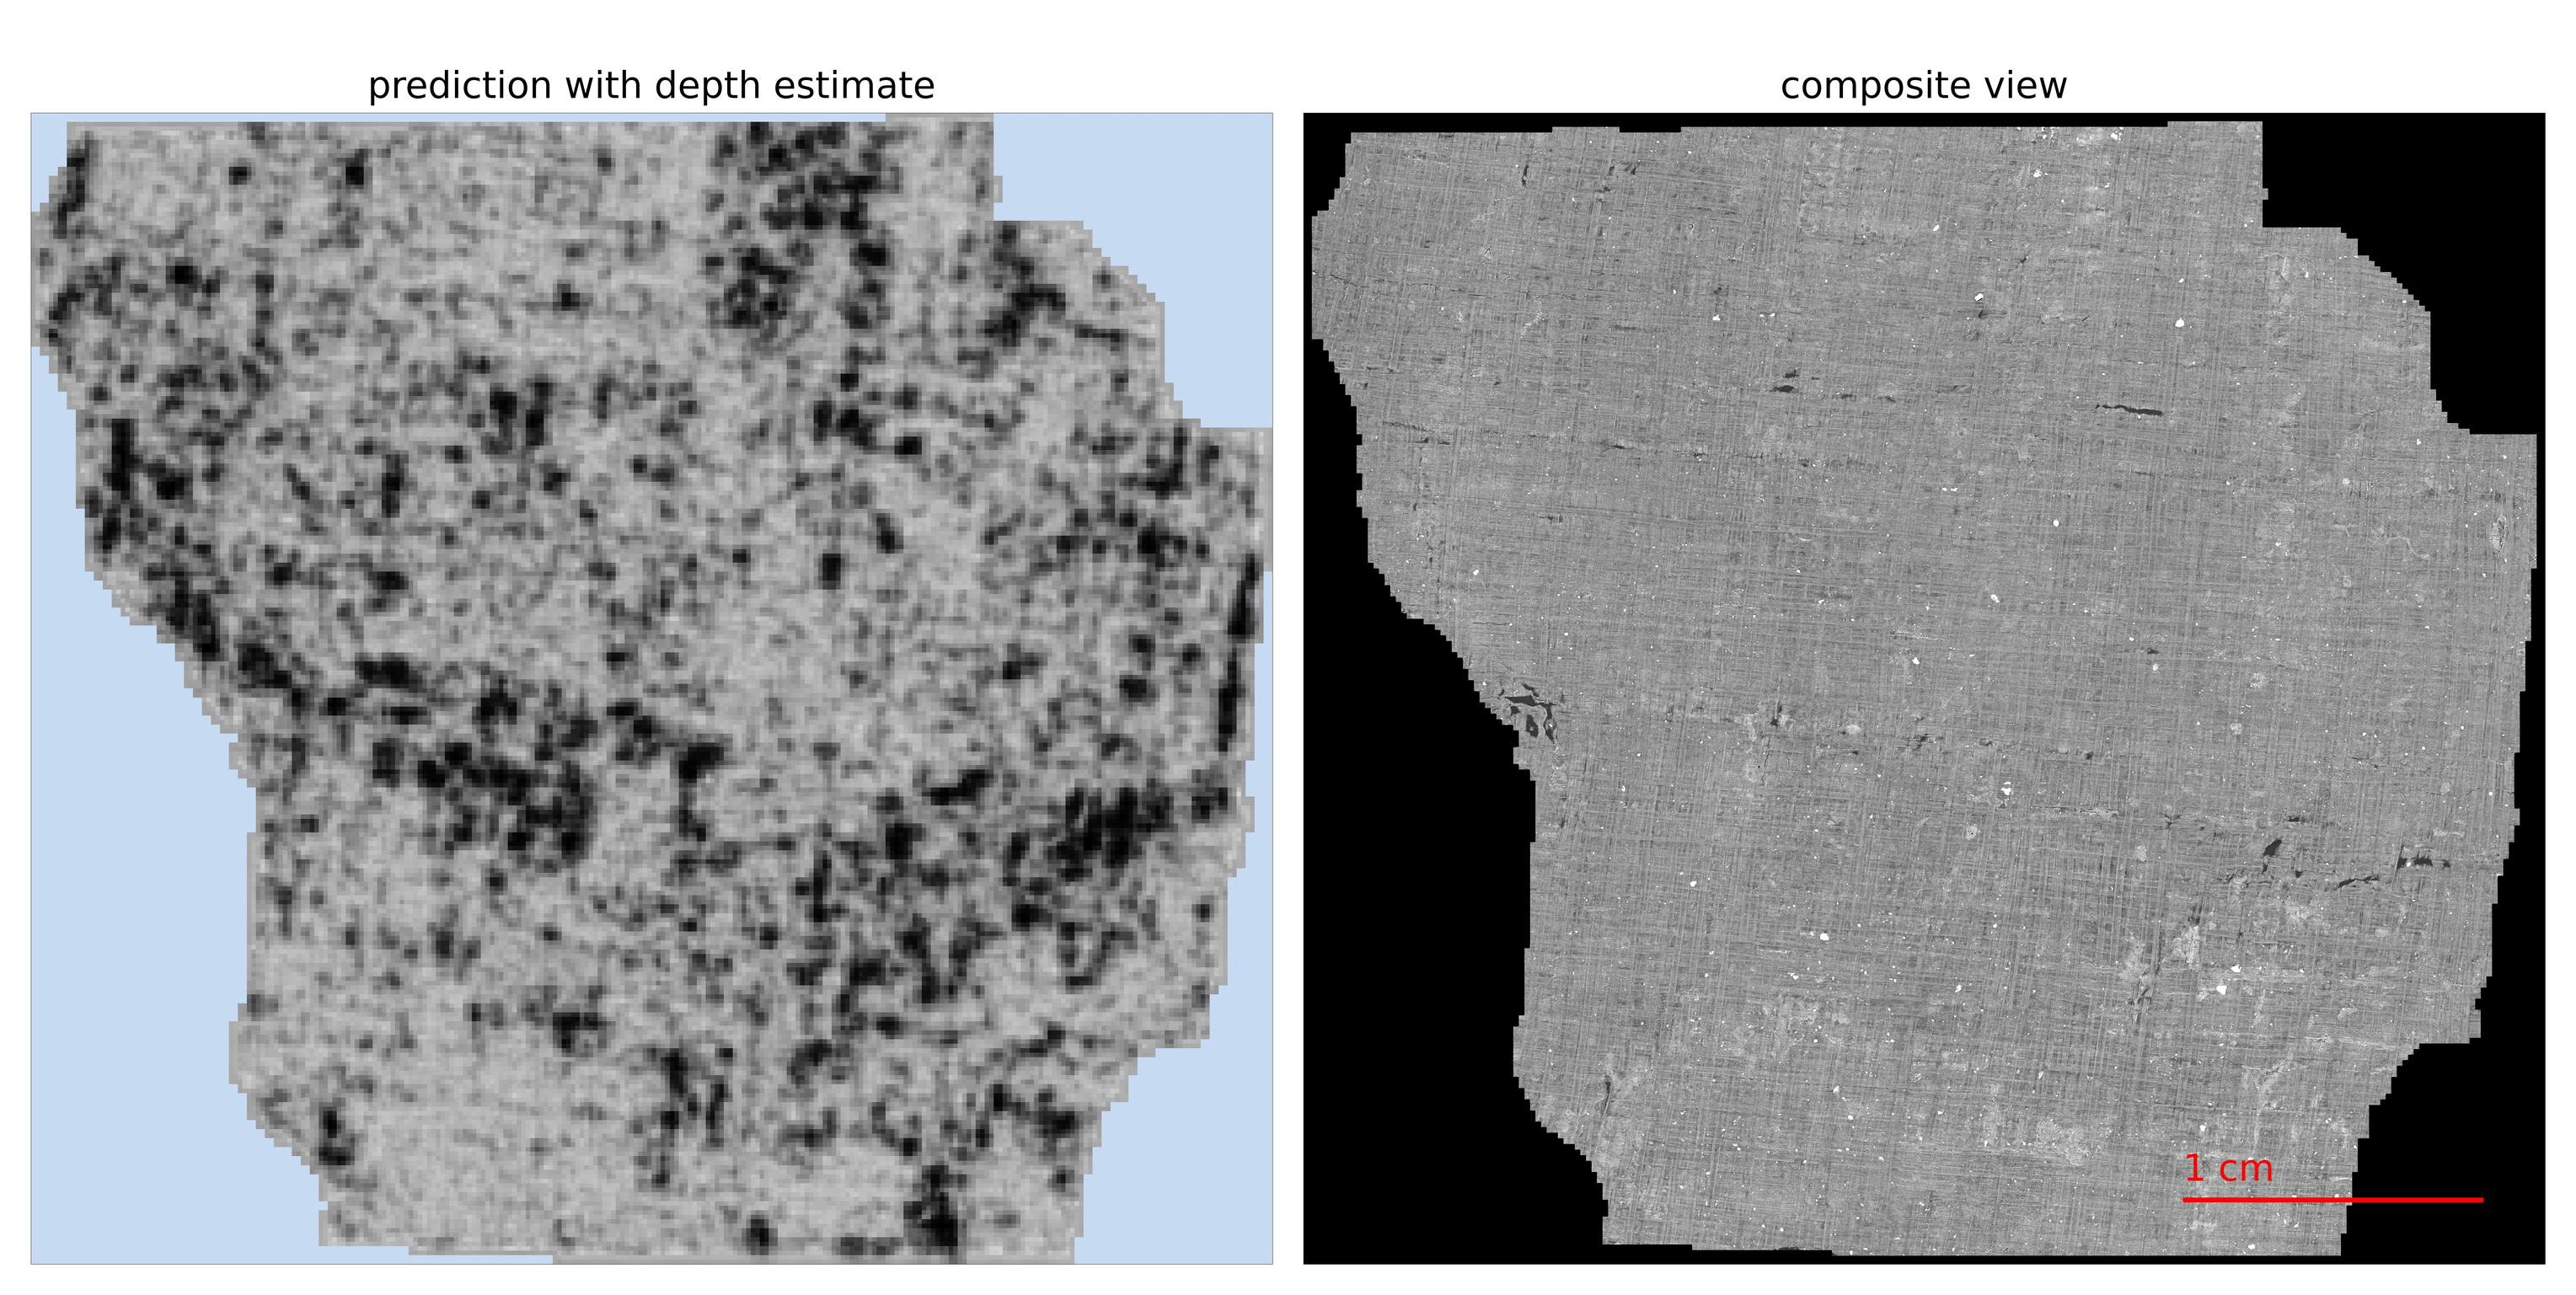


[holdout_n96_surface_norm] 38_holdout_n96_surface_norm_29_20-09-34 norm=surface_anchor fiber=False
[preload] 20260928000003 bbox=(0, 4101, 0, 4421) -> RAM ... done in 1.7s
[predict] reading 14030 tiles in 127 row-strips (test_20260928000003_surface+0)


[predict] test_20260928000003_surface+0 done in  11.2s  predict   7.4s (65.6%)  read/wait   3.9s (34.4%)  [prefetch x3]
[saved] output/test_visualizations/38_holdout_n96_surface_norm_29_20-09-34/PHerc0211_z7312_w080_abf_fast.jpg (fast) bbox=(0, 4101, 0, 4421)


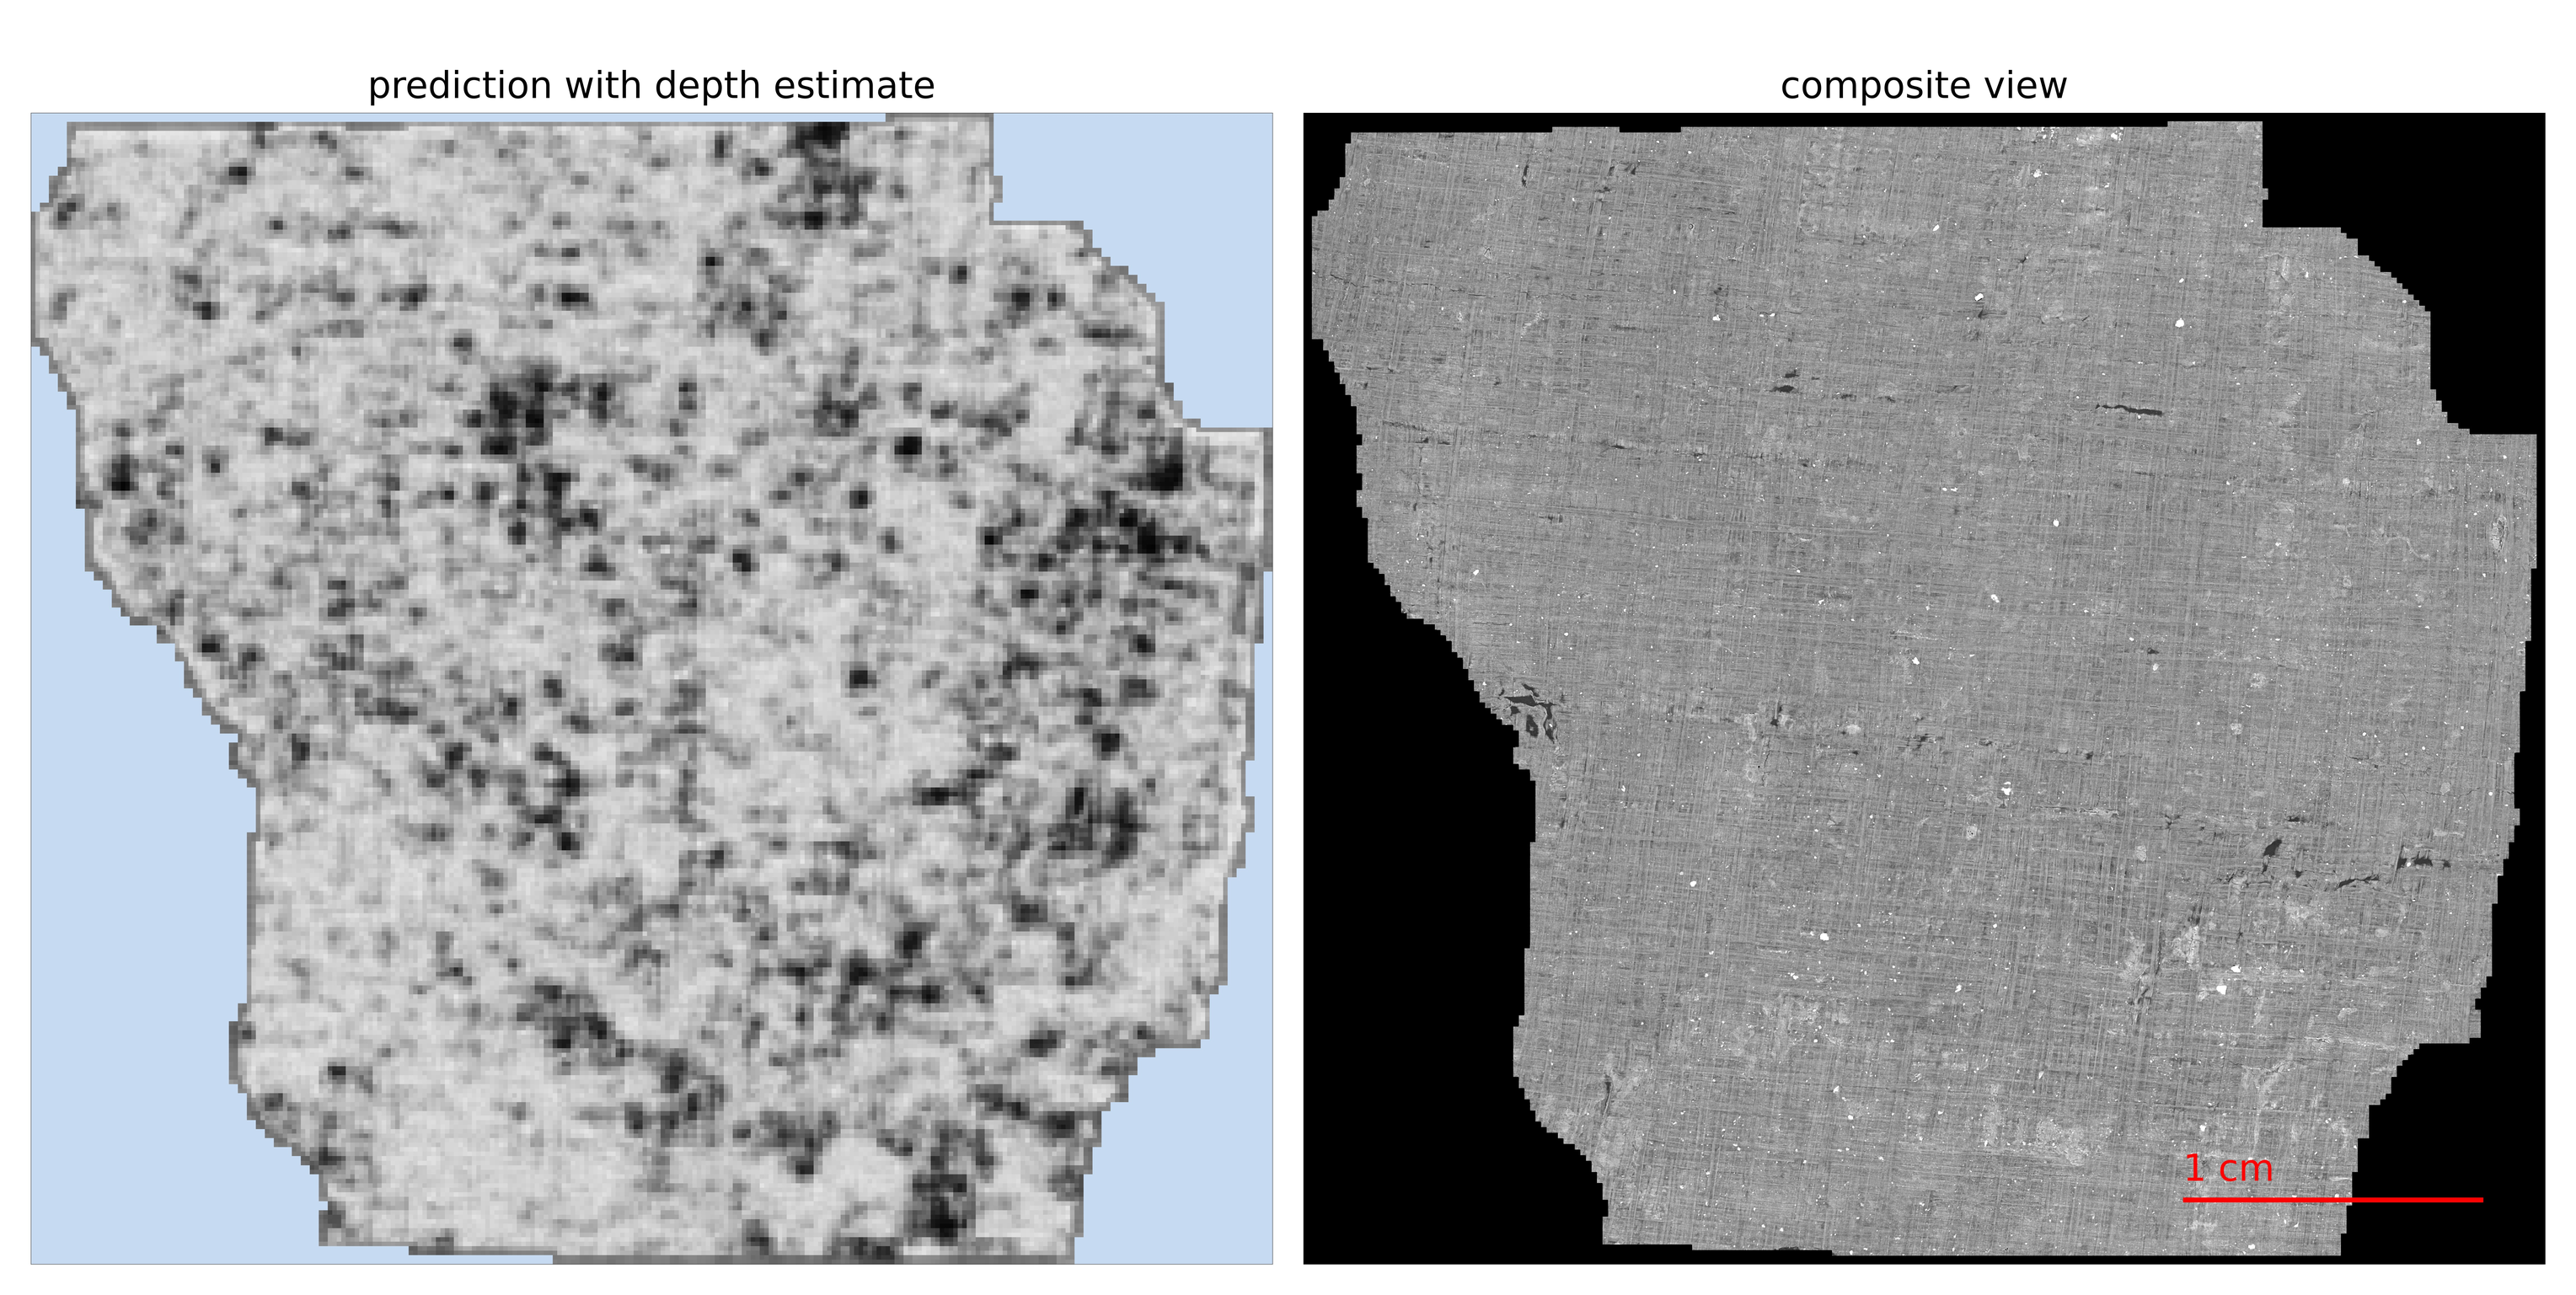

In [22]:
# --- target fragment: PHerc0211 expanded auto-winder segment, rendered for both campaign-38 models ---
NAME = TARGET_NAME
ensure_fragment_ready(MODEL_BUNDLES[0]["config"], TARGET_SCROLL_ID)
for bundle in MODEL_BUNDLES:
    run_info = bundle["run"]
    config = bundle["config"]
    model = bundle["model"]
    print(
        f"\n[{run_info['name']}] {run_info['run_id']} norm={config.data.norm_mode} fiber={config.model.fiber_coordinate_branch}",
        flush=True,
    )
    render_fragment(NAME, TARGET_SCROLL_ID, model, config, run_info)
